# Entrenamiento del GPT decoder-only

Este notebook entrena un modelo GPT decoder-only en español con dos estilos:
- **Wiki**: textos enciclopédicos de Wikipedia en español
- **Poem**: poemas del dataset PoemasDelAlma


## 1. Imports y configuración

In [1]:
import os, re, time, math, random, hashlib
from itertools import islice
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm

from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.trainers import BpeTrainer
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

# Importamos el modelo desde experiments/
import sys
sys.path.insert(0, "..")
from models.gpt_model import GPT

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# Rutas
POEMS_CSV_PATH  = "../data/PoemasDelAlmaDataset.csv"
TOKENIZER_DIR   = "../tokenizer_mix_es"
TOKENIZER_JSON  = os.path.join(TOKENIZER_DIR, "tokenizer.json")
CHECKPOINT_DIR  = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_TOKENIZER = True   # False para reusar tokenizer ya entrenado

# Semilla
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

### Hiperparámetros

In [3]:
# Tokenizer
VOCAB_SIZE                  = 32_000
MIN_FREQ                    = 2
TOKENIZER_TRAIN_WIKI_ARTICLES = 60_000

# Modelo
block_size = 384
n_layers   = 8
d_model    = 512
n_heads    = 8
d_ff       = 2048
dropout    = 0.06

# Entrenamiento
batch_size       = 8
grad_accum_steps = 8
effective_batch  = batch_size * grad_accum_steps
base_lr          = 2e-4
betas            = (0.9, 0.95)
weight_decay     = 0.01
max_opt_steps    = 25_000
warmup_opt_steps = 800
log_every        = 50
eval_every       = 500

# Pesos por estilo
W_WIKI     = 1.00
W_POEM     = 0.70
LS_WIKI    = 0.03    # label smoothing wiki
LS_POEM    = 0.01    # label smoothing poem
STYLE_AUX_W = 0.3   # peso de la pérdida auxiliar de estilo

# Checkpoints
SAVE_EVERY_OPT_STEPS = 500
KEEP_LAST_N          = 5
SAVE_BEST_ON         = "wiki"   # métrica para guardar el mejor checkpoint

STYLE_WIKI = 0
STYLE_POEM = 1
SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<wiki>", "<poem>", "<sep>", "<nl>"]

print(f"effective_batch: {effective_batch} secuencias")
print(f"tokens/opt_step: {effective_batch * block_size:,}")

effective_batch: 64 secuencias
tokens/opt_step: 24,576


## 2. Curriculum y utilidades de texto

In [4]:
def p_poem_schedule(step, warm=3000, start=0.10, end=0.30):
    """Probabilidad de muestrear un poema en función del paso de entrenamiento."""
    if step <= 0: return start
    if step >= warm: return end
    return start + (end - start) * (step / warm)

CUT_HEADERS = [
    "Referencias", "Enlaces externos", "Véase también", "Bibliografía",
    "Notas", "Filmografía", "Discografía", "Premios", "Galería"
]

def clean_wiki_text(t: str) -> str:
    t = t.replace("\r", "\n")
    t = re.sub(r"\n{3,}", "\n\n", t)
    t = re.sub(r"[ \t]+", " ", t)
    t = re.sub(r"[ \t]*\n[ \t]*", "\n", t).strip()

    for h in CUT_HEADERS:
        m = re.search(rf"\b{re.escape(h)}\b", t)
        if m and m.start() > 400:
            t = t[:m.start()].strip()
            break

    t = re.sub(r"\bISBN\b.*?$", "", t, flags=re.IGNORECASE).strip()
    return t

def clean_poem_text(t: str) -> str:
    if t is None:
        return ""
    t = str(t).replace("\r", "\n")
    t = re.sub(r"[ \t]+", " ", t)
    t = re.sub(r"\n{3,}", "\n\n", t).strip()
    return t

def norm_for_hash(t: str) -> str:
    t = t.lower().strip()
    t = re.sub(r"\s+", " ", t)
    return t

def stable_hash(s: str) -> int:
    return int(hashlib.md5(s.encode("utf-8")).hexdigest(), 16)

# Para el tokenizer representamos salto de línea como <nl>
def text_to_tok_text(t: str) -> str:
    return t.replace("\n", " <nl> ")

## 3. Dataset de poemas

In [5]:
dfp = pd.read_csv(POEMS_CSV_PATH)
print("Columnas:", dfp.columns.tolist())
print("Total filas:", len(dfp))
dfp.head(3)

Columnas: ['Title', 'Poem', 'Author']
Total filas: 14750


,Title,Poem,Author
0,Desvaríos,\n\n\r\nEntre nosotros crece la ropa en las ma...,Ángeles Mastretta
1,Caminito del indio,"\n\n\r\nCaminito del indio,\n\r\nsendero coya\...",Atahualpa Yupanqui
2,El poeta,Tú piensas que eres distinto\n\r\nporque te di...,Atahualpa Yupanqui


In [6]:
def clean_poem_record(row):
    title  = str(row.get("Title",  "")).strip()
    poem   = str(row.get("Poem",   "")).strip()
    author = str(row.get("Author", "")).strip()
    if poem == "" or poem.lower() == "nan":
        return None
    poem = poem.replace("\r", "\n")
    poem = re.sub(r"[ \t]+", " ", poem)
    poem = re.sub(r"\n{3,}", "\n\n", poem).strip().strip('"').strip()
    parts = []
    if title  and title.lower()  != "nan": parts.append(f"Título: {title}")
    if author and author.lower() != "nan": parts.append(f"Autor: {author}")
    header = " | ".join(parts)
    return (header + "\n\n" + poem) if header else poem

raw_poems = [p for _, row in dfp.iterrows()
             if (p := clean_poem_record(row)) and len(p) >= 40]
print(f"Raw poems: {len(raw_poems)}")

# Deduplicación por hash
seen, poems_dedup = set(), []
for p in raw_poems:
    h = stable_hash(norm_for_hash(p))
    if h not in seen:
        seen.add(h); poems_dedup.append(p)
print(f"Dedup poems: {len(poems_dedup)}")

# Split 90/10 determinista por hash
poems_train, poems_val = [], []
for p in poems_dedup:
    r = (stable_hash(norm_for_hash(p)) % 10_000) / 10_000.0
    (poems_val if r < 0.10 else poems_train).append(p)
print(f"Train: {len(poems_train)} | Val: {len(poems_val)}")

Raw poems: 14726
Dedup poems: 13105
Train: 11780 | Val: 1325


## 4. Tokenizer BPE

In [7]:
def train_tokenizer():
    os.makedirs(TOKENIZER_DIR, exist_ok=True)
    tmp_path = "mix_texts.txt"

    stream_tok = load_dataset("wikimedia/wikipedia", "20231101.es", split="train", streaming=True)
    stream_tok = stream_tok.shuffle(buffer_size=10_000, seed=SEED)

    TOKENIZER_TRAIN_POEMS = len(poems_train)

    with open(tmp_path, "w", encoding="utf-8") as f:
        for ex in islice(stream_tok, TOKENIZER_TRAIN_WIKI_ARTICLES):
            t = ex.get("text", None)
            if not t:
                continue
            t = clean_wiki_text(t)
            if len(t) < 400:
                continue
            f.write(text_to_tok_text(t) + "\n")

        sample_poems = poems_train
        if TOKENIZER_TRAIN_POEMS > 200_000:
            sample_poems = random.sample(poems_train, k=200_000)

        for p in sample_poems:
            p = clean_poem_text(p)
            f.write(text_to_tok_text(p) + "\n")

    tok = Tokenizer(BPE(unk_token=None))
    tok.pre_tokenizer = ByteLevel(add_prefix_space=True)
    tok.decoder = ByteLevelDecoder()

    trainer = BpeTrainer(
        vocab_size=VOCAB_SIZE,
        min_frequency=MIN_FREQ,
        special_tokens=SPECIAL_TOKENS,
        show_progress=True
    )
    tok.train([tmp_path], trainer)

    tok.save(TOKENIZER_JSON)
    print("Tokenizer saved:", TOKENIZER_JSON)
    return tok

def load_tokenizer():
    tok = Tokenizer.from_file(TOKENIZER_JSON)
    return tok

if TRAIN_TOKENIZER or (not os.path.exists(TOKENIZER_JSON)):
    tokenizer = train_tokenizer()
else:
    tokenizer = load_tokenizer()
    print("Tokenizer loaded:", TOKENIZER_JSON)

vocab = tokenizer.get_vocab()
pad_id = vocab["<pad>"]
bos_id = vocab["<bos>"]
eos_id = vocab["<eos>"]
wiki_tok_id = vocab["<wiki>"]
poem_tok_id = vocab["<poem>"]
sep_id = vocab["<sep>"]
nl_id  = vocab["<nl>"]

vocab_size = tokenizer.get_vocab_size()
print(
    "Vocab size:", vocab_size,
    "| PAD:", pad_id, "| BOS:", bos_id, "| EOS:", eos_id,
    "| <wiki>:", wiki_tok_id, "| <poem>:", poem_tok_id,
    "| SEP:", sep_id, "| NL:", nl_id
)

Tokenizer saved: ../tokenizer_mix_es\tokenizer.json
Vocab size: 32000 | PAD: 0 | BOS: 1 | EOS: 2 | <wiki>: 3 | <poem>: 4 | SEP: 5 | NL: 6


## 5. Datasets y DataLoaders

In [8]:
def _make_prefix(style_idx: int):
    # <bos> <style_token> <sep> texto... <eos>
    style_token = wiki_tok_id if style_idx == STYLE_WIKI else poem_tok_id
    return [bos_id, style_token, sep_id]

def _encode_text(text: str):
    text = text_to_tok_text(text)
    return tokenizer.encode(text).ids

def _chunk_doc_ids(ids, block_size, stride=None, pad_to_full=True):
    if stride is None:
        stride = block_size

    if len(ids) < 2:
        return

    full_len = block_size + 1

    if len(ids) < full_len:
        if not pad_to_full:
            return
        padded = ids + [pad_id] * (full_len - len(ids))
        real_y = max(0, len(ids) - 1)
        mask = [1.0] * real_y + [0.0] * (block_size - real_y)
        x = torch.tensor(padded[:-1], dtype=torch.long)
        y = torch.tensor(padded[1:], dtype=torch.long)
        m = torch.tensor(mask, dtype=torch.float32)
        yield x, y, m
        return

    last_start = len(ids) - full_len
    for start in range(0, last_start + 1, stride):
        chunk = ids[start:start + full_len]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        m = torch.ones(block_size, dtype=torch.float32)
        yield x, y, m

def wiki_hash01(ex):
    h = hashlib.md5(str(ex.get("id", ex.get("title", ""))).encode()).hexdigest()
    return int(h, 16) % 10_000

class WikiDocsStream(IterableDataset):
    def __init__(self, hf_stream, block_size=384, max_articles=None, min_chars=200,
                 style_idx=STYLE_WIKI, split_fn=None, stride=None, pad_to_full=True):
        self.hf_stream = hf_stream
        self.block_size = block_size
        self.max_articles = max_articles
        self.min_chars = min_chars
        self.style_idx = style_idx
        self.split_fn = split_fn
        self.stride = stride
        self.pad_to_full = pad_to_full

    def __iter__(self):
        n = 0
        for ex in self.hf_stream:
            if self.split_fn is not None and not self.split_fn(ex):
                continue
            if self.max_articles is not None and n >= self.max_articles:
                break

            t = ex.get("text", None)
            if not t:
                continue
            t = clean_wiki_text(t)
            if len(t) < self.min_chars:
                continue

            ids = _make_prefix(self.style_idx) + _encode_text(t) + [eos_id]
            n += 1
            for x, y, m in _chunk_doc_ids(ids, self.block_size, stride=self.stride, pad_to_full=self.pad_to_full):
                yield x, y, m, self.style_idx

class PoemDocsDataset(IterableDataset):
    def __init__(self, poems_list, block_size=384, style_idx=STYLE_POEM,
                 shuffle=True, seed=123, repeat=True, stride=None, pad_to_full=True, min_chars=50):
        self.poems_list = poems_list
        self.block_size = block_size
        self.style_idx = style_idx
        self.shuffle = shuffle
        self.seed = seed
        self.repeat = repeat
        self.stride = stride
        self.pad_to_full = pad_to_full
        self.min_chars = min_chars

    def __iter__(self):
        worker = torch.utils.data.get_worker_info()
        wid = 0 if worker is None else worker.id
        rng = random.Random(self.seed + 9973 * wid)

        idxs = list(range(len(self.poems_list)))

        def one_pass():
            if self.shuffle:
                rng.shuffle(idxs)
            for i in idxs:
                t = self.poems_list[i]
                if not t or len(t) < self.min_chars:
                    continue
                ids = _make_prefix(self.style_idx) + _encode_text(t) + [eos_id]
                for x, y, m in _chunk_doc_ids(ids, self.block_size, stride=self.stride, pad_to_full=self.pad_to_full):
                    yield x, y, m, self.style_idx

        if self.repeat:
            while True:
                yield from one_pass()
        else:
            yield from one_pass()

class MixedStreamCurriculum(IterableDataset):
    def __init__(self, wiki_iterable, poem_iterable, p_poem_schedule, seed=42):
        self.wiki_iterable = wiki_iterable
        self.poem_iterable = poem_iterable
        self.p_poem_schedule = p_poem_schedule
        self.seed = seed

    def __iter__(self):
        worker = torch.utils.data.get_worker_info()
        wid = 0 if worker is None else worker.id
        rng = random.Random(self.seed + 10007 * wid)

        wiki_it = iter(self.wiki_iterable)
        poem_it = iter(self.poem_iterable)

        step = 0
        while True:
            p_poem = float(self.p_poem_schedule(step))
            if rng.random() < p_poem:
                x, y, m, sidx = next(poem_it)
            else:
                x, y, m, sidx = next(wiki_it)
            yield x, y, m, sidx
            step += 1

def collate_quad(batch):
    xs, ys, ms, ss = zip(*batch)
    x = torch.stack(xs, dim=0)
    y = torch.stack(ys, dim=0)
    m = torch.stack(ms, dim=0)
    s = torch.tensor(ss, dtype=torch.long)
    return x, y, m, s

In [9]:
wiki_stream_train = load_dataset("wikimedia/wikipedia", "20231101.es", split="train", streaming=True)
wiki_stream_train = wiki_stream_train.shuffle(buffer_size=5000, seed=123)

wiki_stream_val = load_dataset("wikimedia/wikipedia", "20231101.es", split="train", streaming=True)
wiki_stream_val = wiki_stream_val.shuffle(buffer_size=2000, seed=999)

wiki_stride = block_size // 2
poem_stride = block_size // 2

wiki_train = WikiDocsStream(
    wiki_stream_train, block_size=block_size, min_chars=200,
    style_idx=STYLE_WIKI, split_fn=lambda ex: wiki_hash01(ex)/10000 >= 0.10, stride=wiki_stride, pad_to_full=True
)
wiki_val = WikiDocsStream(
    wiki_stream_val, block_size=block_size, max_articles=3000, min_chars=200,
    style_idx=STYLE_WIKI, split_fn=lambda ex: wiki_hash01(ex)/10000 < 0.10, stride=wiki_stride, pad_to_full=True
)

poem_train = PoemDocsDataset(
    poems_train, block_size=block_size, style_idx=STYLE_POEM,
    shuffle=True, seed=11, repeat=True, stride=poem_stride, pad_to_full=True, min_chars=50
)
poem_val = PoemDocsDataset(
    poems_val, block_size=block_size, style_idx=STYLE_POEM,
    shuffle=False, seed=22, repeat=False, stride=poem_stride, pad_to_full=True, min_chars=1
)

train_mix = MixedStreamCurriculum(
    wiki_train, poem_train,
    p_poem_schedule=lambda step: p_poem_schedule(step, warm=3000, start=0.10, end=0.30),
    seed=SEED
)

train_loader = DataLoader(train_mix, batch_size=batch_size, num_workers=0, pin_memory=True, collate_fn=collate_quad)
wiki_val_loader = DataLoader(wiki_val, batch_size=batch_size, num_workers=0, pin_memory=True, collate_fn=collate_quad)
poem_val_loader = DataLoader(poem_val, batch_size=batch_size, num_workers=0, pin_memory=True, collate_fn=collate_quad)

## 6. Modelo y optimizador

In [10]:
config_dict = dict(vocab_size=vocab_size, block_size=block_size,
                   n_layers=n_layers, d_model=d_model, n_heads=n_heads,
                   d_ff=d_ff, dropout=dropout, n_styles=2)
special_ids_dict = dict(pad_id=pad_id, bos_id=bos_id, eos_id=eos_id,
                        wiki_tok_id=wiki_tok_id, poem_tok_id=poem_tok_id,
                        sep_id=sep_id, nl_id=nl_id,
                        STYLE_WIKI=0, STYLE_POEM=1)

model = GPT(**config_dict).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros: {n_params/1e6:.1f}M")

# Optimizador con weight decay selectivo
decay, no_decay = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if p.dim() == 1 or name.endswith(".bias"):
        no_decay.append(p)
    else:
        decay.append(p)

optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": weight_decay},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=base_lr, betas=betas, fused=(device.type=="cuda")
)

def lr_for_opt_step(s):
    if s < warmup_opt_steps:
        return base_lr * (s + 1) / warmup_opt_steps
    progress = (s - warmup_opt_steps) / max(1, (max_opt_steps - warmup_opt_steps))
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    min_lr_frac = 0.02
    return base_lr * (min_lr_frac + (1 - min_lr_frac) * cosine)

scaler = GradScaler(enabled=(device.type=="cuda"))

Parámetros: 43.7M


In [11]:
def save_checkpoint(path, model, optimizer, scaler, opt_step, micro_step,
                    config_dict, tokenizer_json_path, special_ids_dict, extra_metrics=None):
    ckpt = dict(
        opt_step=opt_step, micro_step=micro_step,
        model_state=model.state_dict(),
        optimizer_state=optimizer.state_dict(),
        scaler_state=scaler.state_dict() if scaler else None,
        config=config_dict, tokenizer_json=str(tokenizer_json_path),
        special_ids=special_ids_dict, extra_metrics=extra_metrics or {},
    )
    torch.save(ckpt, path)

def rotate_checkpoints(prefix="step_", keep_last=5):
    files = sorted(CHECKPOINT_DIR.glob(f"{prefix}*.pt"))
    for f in files[:-keep_last]:
        try: f.unlink()
        except: pass

## 7. Bucle de entrenamiento

In [13]:
def masked_ce_loss(logits, targets, mask, label_smoothing=0.0):
    B, T, V = logits.shape
    per_tok = F.cross_entropy(
        logits.view(-1, V), targets.view(-1),
        reduction="none", label_smoothing=label_smoothing
    ).view(B, T)
    denom = mask.sum().clamp_min(1.0)
    return (per_tok * mask).sum() / denom

@torch.no_grad()
def eval_loss(model, loader, n_batches=40, label_smoothing=0.0):
    model.eval()
    losses = []
    it = iter(loader)
    for _ in range(n_batches):
        x, y, m, style_idx = next(it)
        x, y, m, style_idx = x.to(device), y.to(device), m.to(device), style_idx.to(device)
        with autocast(device_type="cuda", enabled=(device.type == "cuda")):
            logits, _ = model(x, style_idx=style_idx, capture=None)
            loss = masked_ce_loss(logits, y, m, label_smoothing=label_smoothing)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

In [14]:
model.train()
optimizer.zero_grad(set_to_none=True)

micro_step = 0
opt_step   = 0
running    = 0.0
best_metric = float("inf")
t0 = time.time()

pbar = tqdm(total=max_opt_steps)

for batch in train_loader:
    x, y, m, style_idx = [t.to(device, non_blocking=True) for t in batch]

    is_poem = (style_idx == STYLE_POEM).float().view(-1, 1)
    w_style = W_POEM * is_poem + W_WIKI * (1.0 - is_poem)

    with autocast(device_type="cuda", enabled=(device.type == "cuda")):
        logits, caches, style_logits = model(
            x, style_idx=style_idx, capture=None,
            return_style_logits=True, pad_id=pad_id
        )
        B, T, V = logits.shape
        ce_w = F.cross_entropy(logits.view(-1,V), y.view(-1),
                                reduction="none", label_smoothing=LS_WIKI).view(B,T)
        ce_p = F.cross_entropy(logits.view(-1,V), y.view(-1),
                                reduction="none", label_smoothing=LS_POEM).view(B,T)
        loss_tok = ce_w * (1.0 - is_poem) + ce_p * is_poem
        lm_loss  = (loss_tok * m * w_style).sum() / (m * w_style).sum().clamp_min(1.0)
        style_loss = F.cross_entropy(style_logits, style_idx)
        loss = lm_loss + STYLE_AUX_W * style_loss

    scaler.scale(loss / grad_accum_steps).backward()
    micro_step += 1

    if micro_step % grad_accum_steps == 0:
        cur_lr = lr_for_opt_step(opt_step)
        for pg in optimizer.param_groups: pg["lr"] = cur_lr

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        optimizer.zero_grad(set_to_none=True)
        opt_step += 1; pbar.update(1)
        running  += loss.item()

        if opt_step % log_every == 0:
            pbar.set_description(f"step {opt_step} | loss {running/log_every:.3f} | lr {cur_lr:.2e}")
            running = 0.0

        if opt_step % eval_every == 0:
            v_wiki = eval_loss(model, wiki_val_loader, n_batches=16, label_smoothing=LS_WIKI)
            v_poem = eval_loss(model, poem_val_loader, n_batches=16, label_smoothing=LS_POEM)
            extra  = {"val_loss_wiki": v_wiki, "val_loss_poem": v_poem, "lr": cur_lr}

            save_checkpoint(CHECKPOINT_DIR/"latest.pt", model, optimizer, scaler,
                            opt_step, micro_step, config_dict, TOKENIZER_JSON,
                            special_ids_dict, extra)
            metric = v_wiki if SAVE_BEST_ON == "wiki" else v_poem
            if metric < best_metric:
                best_metric = metric
                save_checkpoint(CHECKPOINT_DIR/"best.pt", model, optimizer, scaler,
                                opt_step, micro_step, config_dict, TOKENIZER_JSON,
                                special_ids_dict, {**extra, "best_metric": best_metric})

            if opt_step % SAVE_EVERY_OPT_STEPS == 0:
                save_checkpoint(CHECKPOINT_DIR/f"step_{opt_step:06d}.pt", model, optimizer,
                                scaler, opt_step, micro_step, config_dict,
                                TOKENIZER_JSON, special_ids_dict, extra)
                rotate_checkpoints(keep_last=KEEP_LAST_N)

            ppl_w = math.exp(v_wiki) if v_wiki < 20 else float("inf")
            ppl_p = math.exp(v_poem) if v_poem < 20 else float("inf")
            print(f"\nstep {opt_step} | wiki loss {v_wiki:.3f} ppl {ppl_w:.1f}"
                  f" | poem loss {v_poem:.3f} ppl {ppl_p:.1f}")

        if opt_step >= max_opt_steps:
            break

pbar.close()
print(f"\nEntrenamiento completado en {(time.time()-t0)/60:.1f} min")

  0%|          | 0/25000 [00:00<?, ?it/s]


step 500 | wiki loss 22.114 ppl inf | poem loss 14.763 ppl 2579618.9

step 1000 | wiki loss 9.428 ppl 12432.5 | poem loss 6.046 ppl 422.4

step 1500 | wiki loss 7.369 ppl 1586.0 | poem loss 4.804 ppl 122.0

step 2000 | wiki loss 6.931 ppl 1023.2 | poem loss 4.566 ppl 96.2

step 2500 | wiki loss 6.848 ppl 941.9 | poem loss 4.505 ppl 90.5

step 3000 | wiki loss 6.702 ppl 814.1 | poem loss 4.417 ppl 82.9

step 3500 | wiki loss 6.627 ppl 755.0 | poem loss 4.300 ppl 73.7

step 4000 | wiki loss 6.524 ppl 681.2 | poem loss 4.244 ppl 69.7

step 4500 | wiki loss 6.442 ppl 627.6 | poem loss 4.176 ppl 65.1

step 5000 | wiki loss 6.377 ppl 588.3 | poem loss 4.093 ppl 59.9

step 5500 | wiki loss 6.267 ppl 527.1 | poem loss 4.023 ppl 55.9

step 6000 | wiki loss 6.187 ppl 486.5 | poem loss 3.976 ppl 53.3

step 6500 | wiki loss 6.093 ppl 442.9 | poem loss 3.916 ppl 50.2

step 7000 | wiki loss 5.994 ppl 401.0 | poem loss 3.876 ppl 48.2

step 7500 | wiki loss 5.924 ppl 373.9 | poem loss 3.835 ppl 46.3


## 8. Generación de muestras

In [15]:
def decode_ids(ids: list[int]) -> str:
    """
    Decodifica una lista de IDs respetando los tokens especiales.
    Sustituye nl_id por salto de línea antes de que el ByteLevelDecoder
    pueda corromper la cadena '<nl>'.
    """
    # IDs de tokens especiales que queremos manejar nosotros
    SPECIAL = {pad_id, bos_id, eos_id, wiki_tok_id, poem_tok_id, sep_id}
    
    segments = []
    current_chunk = []

    for tid in ids:
        if tid == nl_id:
            # Vuelca el chunk BPE acumulado y añade el salto de línea
            if current_chunk:
                segments.append(tokenizer.decode(current_chunk))
                current_chunk = []
            segments.append("\n")
        elif tid in SPECIAL:
            # Descarta otros tokens especiales
            if current_chunk:
                segments.append(tokenizer.decode(current_chunk))
                current_chunk = []
        else:
            current_chunk.append(tid)

    if current_chunk:
        segments.append(tokenizer.decode(current_chunk))

    text = "".join(segments)
    text = re.sub(r"[ \t]*\n[ \t]*", "\n", text)  # limpia espacios alrededor de \n
    return text

def build_input_ids(prompt: str, style_idx: int, add_eos=False):
    ids = _make_prefix(style_idx)
    ids += _encode_text(prompt)
    if add_eos:
        ids += [eos_id]
    return ids


def _apply_top_k_top_p_1d(logits_1d, top_k=0, top_p=1.0):
    if top_k is not None and top_k > 0:
        top_k = min(top_k, logits_1d.size(-1))
        vals, idx = torch.topk(logits_1d, top_k)
        mask = torch.full_like(logits_1d, float("-inf"))
        mask.scatter_(0, idx, vals)
        logits_1d = mask

    if top_p is not None and 0.0 < top_p < 1.0:
        sorted_logits, sorted_idx = torch.sort(logits_1d, descending=True)
        probs = F.softmax(sorted_logits, dim=-1)
        cumprobs = torch.cumsum(probs, dim=-1)

        cutoff = cumprobs > top_p
        cutoff[..., 1:] = cutoff[..., :-1].clone()
        cutoff[..., 0] = False

        sorted_logits[cutoff] = float("-inf")
        logits2 = torch.empty_like(logits_1d)
        logits2.scatter_(0, sorted_idx, sorted_logits)
        logits_1d = logits2

    return logits_1d

def _ban_repeated_ngrams(logits, generated_ids, no_repeat_ngram_size=3):
    n = no_repeat_ngram_size
    if n is None or n <= 0 or len(generated_ids) < n:
        return logits
    prefix = tuple(generated_ids[-(n-1):])
    banned = set()
    for i in range(len(generated_ids) - n + 1):
        if tuple(generated_ids[i:i+n-1]) == prefix:
            banned.add(generated_ids[i+n-1])
    if banned:
        logits[list(banned)] = -1e10
    return logits

@torch.no_grad()
def generate(model, prompt, style="wiki", max_new_tokens=160,
             temperature=0.9, top_p=0.95, top_k=0,
             presence_penalty=0.15, frequency_penalty=0.05,
             no_repeat_ngram_size=3, do_sample=True):

    model.eval()
    style_idx = STYLE_WIKI if style == "wiki" else STYLE_POEM

    ids = build_input_ids(prompt, style_idx=style_idx, add_eos=False)
    x = torch.tensor([ids], dtype=torch.long, device=device)
    sidx = torch.tensor([style_idx], dtype=torch.long, device=device)

    counts = torch.zeros(vocab_size, device=device, dtype=torch.float32)
    for tid in x[0]:
        counts[tid] += 1.0

    for _ in range(max_new_tokens):
        logits, _ = model(x, style_idx=sidx, capture=None)
        next_logits = logits[0, -1].float()

        if temperature and temperature > 0:
            next_logits = next_logits / temperature

        if presence_penalty or frequency_penalty:
            seen = (counts > 0).float()
            next_logits = next_logits - presence_penalty * seen - frequency_penalty * counts

        if no_repeat_ngram_size and no_repeat_ngram_size > 0:
            next_logits = _ban_repeated_ngrams(next_logits, x[0].tolist(), no_repeat_ngram_size)

        next_logits = _apply_top_k_top_p_1d(next_logits, top_k=top_k, top_p=top_p)

        if do_sample:
            probs = F.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
        else:
            next_token = torch.argmax(next_logits, dim=-1, keepdim=True)

        tid = next_token.item()
        x = torch.cat([x, next_token.view(1, 1)], dim=1)
        counts[tid] += 1.0

        if tid == eos_id:
            break

    out_ids = x[0].tolist()

    # Quita prefijo si está presente: <bos> <style> <sep>
    if len(out_ids) >= 3 and out_ids[0] == bos_id and out_ids[2] == sep_id:
        out_ids = out_ids[3:]
    elif len(out_ids) >= 1 and out_ids[0] == bos_id:
        out_ids = out_ids[1:]

    while len(out_ids) > 0 and out_ids[-1] == eos_id:
        out_ids = out_ids[:-1]

    return decode_ids(out_ids)

In [19]:
print("\n=== WIKI PROMPT ===")
print(generate(model, "La historia de España", style="wiki",
               max_new_tokens=200,
               temperature=0.7, top_p=0.9, top_k=50,
               presence_penalty=0.2, frequency_penalty=0.15,
               no_repeat_ngram_size=4, do_sample=True))


=== WIKI PROMPT ===
 La historia de España es una de las grandes regiones del país. La historia de la historia de España se ubica en la ciudad de España, en la ciudad el 28 de mayo de 2022. La historia se halla en la ciudad.

Historia
La historia de los últimos años se publicó en el año 2019 en el que se estableció la historia del país.
La obra fue la primera de los primeros años de edad, aunque no se ha conservado. El premio es el premio más alto de España, con el título de "Mat-Pat-Bruya". En la segunda temporada, en la que el premio fue fundado por el premio "Lanf-Bruda", el premio "Over-Sad-Gol" y "Bruda" en el año 2020.
El premio "Len-Gol", fue un premio a los 15 años del año 2020. Se trata de una historia para el premio "The Putt-


In [18]:
print("\n=== POEM PROMPT ===")
print(generate(model, "En la noche silenciosa", style="poem",
               max_new_tokens=200,
               temperature=0.9, top_p=0.95, top_k=50,
               presence_penalty=0.25, frequency_penalty=0.10,
               no_repeat_ngram_size=3, do_sample=True))


=== POEM PROMPT ===
 En la noche silenciosa

En la mañana de un viejo dolor que no se la tiara
.
Las ardorosas se me desvelan
...
Si nadie sabes que no sea en el fondo
El último mar mi amor se conoce como un hombre que se hace un hombre,
a la luna, se sabe que, al fin de ellos,   sonreía el sol y el sol, a su padre en la palabra.   en la noche, la noche se ha llegado.
, donde su cuerpo no es el más joven.


# 9. Curva de pérdida

In [1]:
import re
import matplotlib.pyplot as plt

log = """
step 500 | wiki loss 22.114 ppl inf | poem loss 14.763 ppl 2579618.9

step 1000 | wiki loss 9.428 ppl 12432.5 | poem loss 6.046 ppl 422.4

step 1500 | wiki loss 7.369 ppl 1586.0 | poem loss 4.804 ppl 122.0

step 2000 | wiki loss 6.931 ppl 1023.2 | poem loss 4.566 ppl 96.2

step 2500 | wiki loss 6.848 ppl 941.9 | poem loss 4.505 ppl 90.5

step 3000 | wiki loss 6.702 ppl 814.1 | poem loss 4.417 ppl 82.9

step 3500 | wiki loss 6.627 ppl 755.0 | poem loss 4.300 ppl 73.7

step 4000 | wiki loss 6.524 ppl 681.2 | poem loss 4.244 ppl 69.7

step 4500 | wiki loss 6.442 ppl 627.6 | poem loss 4.176 ppl 65.1

step 5000 | wiki loss 6.377 ppl 588.3 | poem loss 4.093 ppl 59.9

step 5500 | wiki loss 6.267 ppl 527.1 | poem loss 4.023 ppl 55.9

step 6000 | wiki loss 6.187 ppl 486.5 | poem loss 3.976 ppl 53.3

step 6500 | wiki loss 6.093 ppl 442.9 | poem loss 3.916 ppl 50.2

step 7000 | wiki loss 5.994 ppl 401.0 | poem loss 3.876 ppl 48.2

step 7500 | wiki loss 5.924 ppl 373.9 | poem loss 3.835 ppl 46.3

step 8000 | wiki loss 5.857 ppl 349.7 | poem loss 3.778 ppl 43.7

step 8500 | wiki loss 5.787 ppl 326.0 | poem loss 3.731 ppl 41.7

step 9000 | wiki loss 5.739 ppl 310.9 | poem loss 3.696 ppl 40.3

step 9500 | wiki loss 5.715 ppl 303.2 | poem loss 3.674 ppl 39.4

step 10000 | wiki loss 5.671 ppl 290.4 | poem loss 3.651 ppl 38.5

step 10500 | wiki loss 5.614 ppl 274.4 | poem loss 3.610 ppl 37.0

step 11000 | wiki loss 5.588 ppl 267.3 | poem loss 3.600 ppl 36.6

step 11500 | wiki loss 5.526 ppl 251.1 | poem loss 3.557 ppl 35.0

step 12000 | wiki loss 5.482 ppl 240.4 | poem loss 3.536 ppl 34.3

step 12500 | wiki loss 5.407 ppl 223.0 | poem loss 3.516 ppl 33.6

step 13000 | wiki loss 5.373 ppl 215.4 | poem loss 3.499 ppl 33.1

step 13500 | wiki loss 5.331 ppl 206.7 | poem loss 3.478 ppl 32.4

step 14000 | wiki loss 5.295 ppl 199.4 | poem loss 3.459 ppl 31.8

step 14500 | wiki loss 5.260 ppl 192.5 | poem loss 3.466 ppl 32.0

step 15000 | wiki loss 5.228 ppl 186.5 | poem loss 3.434 ppl 31.0

step 15500 | wiki loss 5.201 ppl 181.5 | poem loss 3.414 ppl 30.4

step 16000 | wiki loss 5.194 ppl 180.3 | poem loss 3.408 ppl 30.2

step 16500 | wiki loss 5.153 ppl 172.9 | poem loss 3.401 ppl 30.0

step 17000 | wiki loss 5.138 ppl 170.4 | poem loss 3.395 ppl 29.8

step 17500 | wiki loss 5.117 ppl 166.8 | poem loss 3.386 ppl 29.6

step 18000 | wiki loss 5.108 ppl 165.4 | poem loss 3.376 ppl 29.3

step 18500 | wiki loss 5.086 ppl 161.8 | poem loss 3.369 ppl 29.0

step 19000 | wiki loss 5.081 ppl 161.0 | poem loss 3.365 ppl 28.9

step 19500 | wiki loss 5.075 ppl 160.0 | poem loss 3.361 ppl 28.8

step 20000 | wiki loss 5.073 ppl 159.7 | poem loss 3.356 ppl 28.7

step 20500 | wiki loss 5.065 ppl 158.4 | poem loss 3.348 ppl 28.4

step 21000 | wiki loss 5.057 ppl 157.1 | poem loss 3.346 ppl 28.4

step 21500 | wiki loss 5.051 ppl 156.1 | poem loss 3.344 ppl 28.3

step 22000 | wiki loss 5.043 ppl 154.9 | poem loss 3.340 ppl 28.2

step 22500 | wiki loss 5.035 ppl 153.8 | poem loss 3.337 ppl 28.1

step 23000 | wiki loss 5.037 ppl 154.0 | poem loss 3.336 ppl 28.1

step 23500 | wiki loss 5.035 ppl 153.7 | poem loss 3.333 ppl 28.0

step 24000 | wiki loss 5.027 ppl 152.5 | poem loss 3.332 ppl 28.0

step 24500 | wiki loss 5.017 ppl 151.0 | poem loss 3.331 ppl 28.0

step 25000 | wiki loss 5.017 ppl 150.9 | poem loss 3.330 ppl 27.9
"""

pattern = r"step (\d+) \| wiki loss ([\d.]+) ppl ([\d.inf]+) \| poem loss ([\d.]+) ppl ([\d.]+)"
rows = re.findall(pattern, log)

steps     = [int(r[0])   for r in rows]
wiki_loss = [float(r[1]) for r in rows]
poem_loss = [float(r[3]) for r in rows]
wiki_ppl  = [float(r[2]) if r[2] != 'inf' else None for r in rows]
poem_ppl  = [float(r[4]) for r in rows]

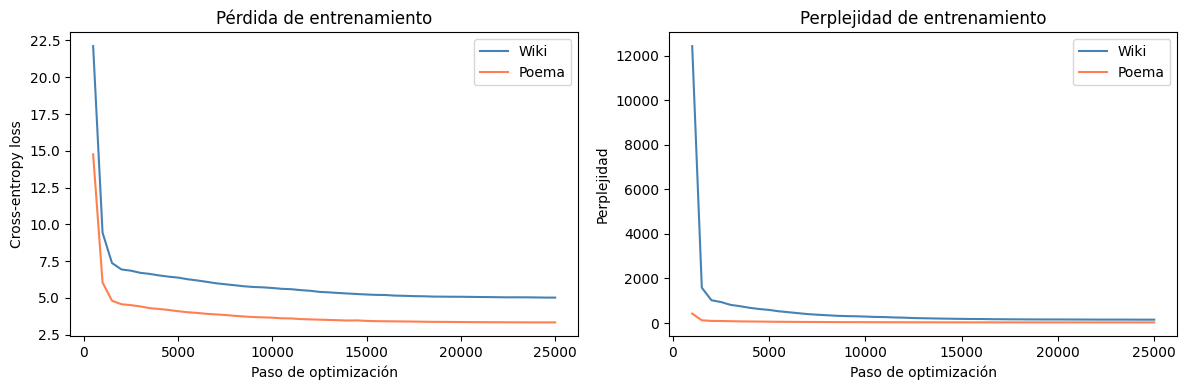

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps, wiki_loss, label='Wiki', color='steelblue')
axes[0].plot(steps, poem_loss, label='Poema', color='coral')
axes[0].set_xlabel('Paso de optimización')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Pérdida de entrenamiento')
axes[0].legend()

axes[1].plot(steps[1:], wiki_ppl[1:], label='Wiki', color='steelblue')
axes[1].plot(steps[1:], poem_ppl[1:], label='Poema', color='coral')
axes[1].set_xlabel('Paso de optimización')
axes[1].set_ylabel('Perplejidad')
axes[1].set_title('Perplejidad de entrenamiento')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')